In [8]:
%matplotlib inline
from pathlib import Path
import click
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.backends.backend_pdf
import matplotlib.style as mplstyle
import os
from datetime import datetime
import matplotlib.colors as mcolors

In [9]:
from hole_trajectory import calculate_trajectory_3d, plot_trajectory_3d, calc_binned_angles, plot_stability_comparison, calc_inclination, plot_inclination

In [10]:
mplstyle.use('fast')
plt.rcParams['lines.markersize'] = 1
plt.rcParams['font.size'] = 14
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['image.cmap'] = "viridis"
plt.rcParams['figure.max_open_warning'] = 50

In [11]:
# Publication-quality settings for this figure
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

In [12]:
from multi_log_reader import MultiLogReader
from preprocess import preprocess
#folder = "/Users/delia/Library/CloudStorage/OneDrive-SharedLibraries-NERC/BAS BigRAID Documents/Season Reports/2025/DataLog" 


In [13]:
# Step cutters vs flat cutters
# Site 14, Hole 5  - got stuck 
folder = "/Users/delia/Library/CloudStorage/OneDrive-SharedLibraries-NERC/BAS BigRAID - Documents/Season Reports/2024/DataLog/" 
start_date="20240625"
end_date="20240626"
print(folder)

#if out_file is None:
#    end_date_str = ""
#    if end_date is not None:
#        end_date_str = f"_{end_date}"
#    out_file = Path(f"BigRAID_{start_date}{end_date_str}.pdf")
#out_file = Path(out_file)
#out_file = out_file.with_name(out_file.name.replace(":", "-"))
#print(out_file)

mr = MultiLogReader.find_files(folder, start_date, end_date)
df = mr.as_df()
df = preprocess(df, run_depth_threshold=1.5)
#_plot(df, out_file)

/Users/delia/Library/CloudStorage/OneDrive-SharedLibraries-NERC/BAS BigRAID - Documents/Season Reports/2024/DataLog/
Error decoding record: err='unpack requires a buffer of 38 bytes', raw='b''', sep='b' ''


GridSpec(1, 2, width_ratios=[0.8, 2])


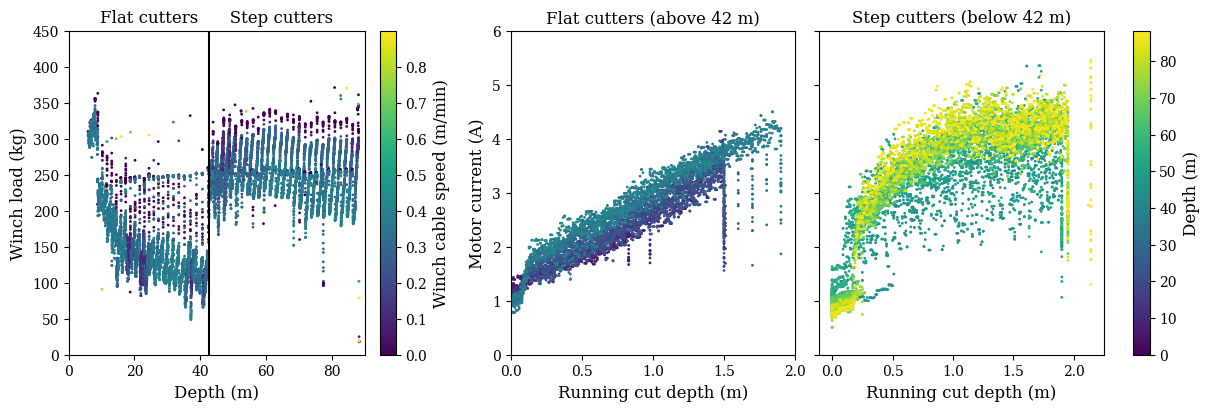

In [17]:
global_min = np.min(df["[PLC]WIRESPOOLEDOUT"])
global_max = np.max(df["[PLC]WIRESPOOLEDOUT"])
norm = mcolors.Normalize(vmin=global_min, vmax=global_max)


fig = plt.figure(figsize=(12, 4))
outer_grid = fig.add_gridspec(1, 2, width_ratios=[0.8,2], wspace=0.05)
axes={}

print(outer_grid)
# Split the left section into two columns that share a Y-axis
left_grid = outer_grid[1].subgridspec(1, 2, wspace=-0.1)
axes[0] = fig.add_subplot(left_grid[0])
axes[1] = fig.add_subplot(left_grid[1],  sharey=axes[0])
# Create the independent right plot
axes[2] = fig.add_subplot(outer_grid[0])

# Plots 1 & 2: Shared color limits (vmin/vmax) and shared y-axis
im1=df[(df["cutting"] == 1) & (df["[PLC]WIRESPOOLEDOUT"] < 42)].plot.scatter(x="cut_depth", y="[PLC]DRILLACTIVECURRENT", c="[PLC]WIRESPOOLEDOUT", s =1, rasterized=True, cmap="viridis", ax = axes[0], norm = norm, colorbar=False)
im2=df[(df["cutting"] == 1) & (df["[PLC]WIRESPOOLEDOUT"]>= 42)].plot.scatter(x="cut_depth", y="[PLC]DRILLACTIVECURRENT", c="[PLC]WIRESPOOLEDOUT", s =1, rasterized=True, cmap="viridis", ax = axes[1], norm = norm, colorbar=False)
# Single colorbar for the first two plots
fig.colorbar(im1.collections[0], ax=[axes[0], axes[1]], orientation='vertical', shrink=1, location='right', label= 'Depth (m)')

axes[0].set_xlabel("Running cut depth (m)")
axes[0].set_ylabel("Motor current (A)")
axes[0].set_ylim(0,6)
axes[0].set_xlim(0,2)
axes[0].set_title('Flat cutters (above 42 m)')
axes[1].set_title('Step cutters (below 42 m)')
axes[1].set_xlabel("Running cut depth (m)")


# Plot 3: Independent axes and colorbar
im3 = df[(df["cutting"] == 1)].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="[PLC]CABLETENSION", c="[PLC]CABLESPEED", s =1, rasterized=True, cmap="viridis", ax = axes[2], colorbar = False)
axes[2].set_xlabel("Depth (m)")
axes[2].set_ylabel("Winch load (kg)")
axes[2].vlines(42.5, ymin = 0, ymax = 450, color = 'k')#, color = 'k')
#ax.text(10,400,"flat cutters")
#ax.text(50,400,"step cutters")
axes[2].set_title("Flat cutters      Step cutters")
axes[2].set_ylim(0,450)
axes[2].set_xlim(0,90)

# Re-enable y-ticks if sharey=True disabled them for the 3rd plot
axes[2].yaxis.set_tick_params(labelleft=True) 
fig.colorbar(im3.collections[0], ax=axes[2], orientation='vertical', shrink=1, location='right', label= 'Winch cable speed (m/min)')
#plt.tight_layout()
plt.savefig("paper_plots/step_vs_flat.pdf")


In [ ]:
# not used anymore
# fig, ax = plt.subplots(1, 1)
# fig.set_figwidth(5.5)
# fig.set_figheight(5)
# img=df[(df["cutting"] == 1)].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="[PLC]CABLETENSION", c="[PLC]CABLESPEED", s =1, rasterized=True, cmap="viridis", ax = ax, colorbar = False)#norm = norm)
# ax.set_xlabel("Depth (m)")
# ax.set_ylabel("Winch load (kg)")
# ax.vlines(42.5, ymin = 0, ymax = 450, color = 'k')#, color = 'k')
# ax.set_title("Flat cutters      Step cutters")
# ax.set_ylim(0,450)
# ax.set_xlim(0,90)
# fig.colorbar(img.collections[0],ax=ax, shrink=1, location='right', label= 'Winch cable speed (m/min)')
# fig.savefig("paper_plots/flat_vs_step_cutters_winch_load.pdf")


In [ ]:
# not used anymore

# fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
# fig.set_figwidth(10)
# fig.set_figheight(5)

# fig.suptitle('')
# global_min = np.min(df["[PLC]WIRESPOOLEDOUT"])
# global_max = np.max(df["[PLC]WIRESPOOLEDOUT"])
# norm = mcolors.Normalize(vmin=global_min, vmax=global_max)

# img1=df[(df["cutting"] == 1) & (df["[PLC]WIRESPOOLEDOUT"] < 42)].plot.scatter(x="cut_depth", y="[PLC]DRILLACTIVECURRENT", c="[PLC]WIRESPOOLEDOUT", s =1, rasterized=True, cmap="viridis", ax = ax1, norm = norm, colorbar=False)
# #plt.title("Motor Current vs Running Cut Depth")
# ax1.set_xlabel("Running cut depth (m)")
# ax1.set_ylabel("Motor current (A)")
# ax1.set_title("Flat cutters")
# ax1.set_ylim(0,6)
# ax1.set_xlim(0,2)

# img2=df[(df["cutting"] == 1) & (df["[PLC]WIRESPOOLEDOUT"] >= 42)].plot.scatter(x="cut_depth", y="[PLC]DRILLACTIVECURRENT", c="[PLC]WIRESPOOLEDOUT", s =1, rasterized=True, cmap="viridis", ax = ax2, norm = norm, colorbar=False)
# #plt.title("Motor Current vs Running Cut Depth")
# ax2.set_xlabel("Running cut depth (m)")
# ax2.set_ylabel("Motor current (A)")
# ax2.set_title("Step cutters")
# ax2.set_ylim(0,6)
# ax2.set_xlim(0,2)


# fig.colorbar(img1.collections[0],ax=[ax1,ax2], shrink=1, location='right', label= 'Depth (m)')
# #fig.tight_layout()
# fig.savefig("paper_plots/flat_vs_step_cutters_winch_load.pdf")
# plt.show()
# #fig.savefig("paper_plots/flat_vs_step_cutters_motor_current_winch_load.pdf")


In [18]:
# Isopropanol plot
label = {}
dataset = {}
# Hole 15 #1 (the last hole of 2024)
folder2024 = "/Users/delia/Library/CloudStorage/OneDrive-SharedLibraries-NERC/BAS BigRAID - Documents/Season Reports/2024/DataLog/" 
start_date="20240703"
end_date="20240726"
label[1]= 'S15-H1 (2024, no isopropanol)'
dataset[1] = MultiLogReader.find_files(folder2024, start_date, end_date).as_df()
#df1 = mr1.as_df()
dataset[1] = preprocess(dataset[1], run_depth_threshold=1.5)

# folder2025 = "/Users/delia/Library/CloudStorage/OneDrive-SharedLibraries-NERC/BAS BigRAID - Documents/Season Reports/2025/DataLog/" 
# start_date="20250614"
# end_date="20250618"
# mr2 = MultiLogReader.find_files(folder2025, start_date, end_date)
# df2 = mr2.as_df()
# df2 = preprocess(df2, run_depth_threshold=1.5)
# 
# Site 15 #2 (the first done in 2025)
folder2025 = "/Users/delia/Library/CloudStorage/OneDrive-SharedLibraries-NERC/BAS BigRAID - Documents/Season Reports/2025/DataLog/" 
start_date="20250614"
end_date="20250618"
label[2]= 'S15-H2 (2025, no isopropanol)'
dataset[2] = MultiLogReader.find_files(folder2025, start_date, end_date).as_df()
#df2 = mr2.as_df()
dataset[2] = preprocess(dataset[2], run_depth_threshold=1.5)

# Site 35 #1
start_date="20250623"
end_date="20250625T12:00:00"
label[3]= 'S35-H1 (2025, isopropanol)'
dataset[3] = MultiLogReader.find_files(folder2025, start_date, end_date).as_df()
#df3 = mr3.as_df()
dataset[3] = preprocess(dataset[3], run_depth_threshold=1.5)

Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error deco

In [ ]:
# fig, (ax1) = plt.subplots(1, 1, sharey=True, sharex=True)
# fig.set_figwidth(10)
# fig.set_figheight(5)
# min_depth = 60
# df[(df["cutting"] == 1)&(df["[PLC]AUTODOWNSTOPDEPTH"]>min_depth)].plot.scatter(x="[PLC]AUTODOWNSTOPDEPTH", y="cut_depth",c = 'tab:blue',s =1,  alpha =0.5, rasterized=True, ax=ax1, label = "Site 15, hole 1 (2024) (no isopropanol)")#, cmap="viridis")
# #plt.title("Running Cut Depth per run")
# #ax1.set_title("Site 15, hole 1 (2024) (no isopropanol)")
# #ax1.set_ylabel("Running Cut Depth [m]")
# #ax1.set_xlabel("Depth [m]")
# ax1.axes.get_yaxis().get_label().set_visible(False)

# ax1.set_xlim(min_depth,100)
# ax1.set_ylim(0,2.5)

# df2[(df2["cutting"] == 1)&(df2["[PLC]AUTODOWNSTOPDEPTH"]>min_depth)].plot.scatter(x="[PLC]AUTODOWNSTOPDEPTH", y="cut_depth",c = 'tab:orange', s =1, alpha =0.5,rasterized=True, ax = ax1,label="Site 15, hole 2 (2025) (no isopropanol)")#, cmap="viridis")
# #df2[(df2["cutting"] == 1)&(df2["[PLC]WIRESPOOLEDOUT"] <=77.2)].plot.scatter(x="run", y="cut_depth",s =1, rasterized=True, ax = ax2)#, cmap="viridis")
# #plt.title("Running Cut Depth per run
# #df2[(df2["cutting"] == 1)&(df2["[PLC]WIRESPOOLEDOUT"] >77.2)].plot.scatter(x="run", y="cut_depth",s =1, c='r',rasterized=True, ax = ax2)#, cmap="viridis")
# #plt.title("Running Cut Depth per run")
# #ax2.set_title("Site 15, hole 2 (2025) (no isopropanol)")
# ax1.axes.get_yaxis().get_label().set_visible(False)

# #ax2.set_ylabel("Running Cut Depth [m]")
# #ax2.set_xlabel("Depth [m]")
# #ax2.set_xlim(min_depth,100)
# #ax2.set_ylim(0,2.5)

# df3[(df3["cutting"] == 1) &(df3["[PLC]AUTODOWNSTOPDEPTH"]>min_depth)].plot.scatter(x="[PLC]AUTODOWNSTOPDEPTH", y="cut_depth",c='tab:green',s =1, alpha =0.5,rasterized=True, ax = ax1, label="Site 35, hole 1 (2025) (isopropanol)")#, cmap="viridis")
# #df2[(df2["cutting"] == 1)&(df2["[PLC]WIRESPOOLEDOUT"] <=77.2)].plot.scatter(x="run", y="cut_depth",s =1, rasterized=True, ax = ax3)#, cmap="viridis")
# #plt.title("Running Cut Depth per run
# #df2[(df2["cutting"] == 1)&(df2["[PLC]WIRESPOOLEDOUT"] >77.2)].plot.scatter(x="run", y="cut_depth",s =1, c='r',rasterized=True, ax = ax2)#, cmap="viridis")
# #plt.title("Running Cut Depth per run")
# #ax3.set_title("Site 35, hole 1 (2025) (isopropanol)")
# #ax3.axes.get_yaxis().get_label().set_visible(False)
# #x_axis.set_label_text('foo')
# #x_label = x_axis.get_label()
# ##print isinstance(x_label, matplotlib.artist.Artist)
# #x_label.set_visible(False)
# #ax3.set_ylabel("Running Cut Depth [m]")
# #ax3.set_xlabel("Depth [m]")
# #ax3.axes.get_xaxis().get_label().set_visible(False)
# #ax3.set_xlim(min_depth,100)
# #ax3.set_ylim(0,2.5)
# ax1.axes.get_xaxis().get_label().set_visible(False)
# leg=ax1.axes.get_legend()
# print(leg.set_title(""))
# fig.suptitle('')
# fig.supylabel("Running Cut Depth [m]")
# fig.supxlabel("Depth [m]")
# #fig.colorbar(img1.collections[0],ax=[ax1,ax2], shrink=1, location='right', label= 'depth [m]')
# #plt.show()
# fig.savefig("cut_depth_by_run_isopropanol.pdf")

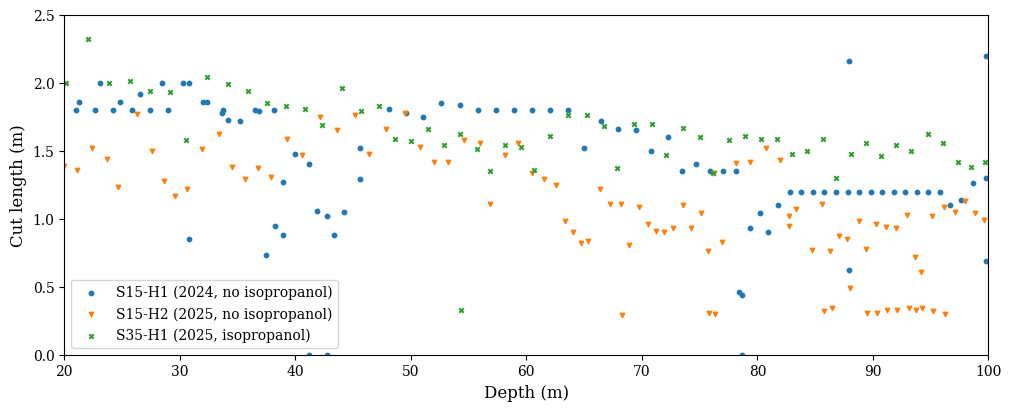

In [19]:
fig = plt.figure()
fig.set_figwidth(10)
fig.set_figheight(4)
ax = plt.subplot()
markers =['o','v','x']
for i in range(1,4):
    d = dataset[i]
    run = d['run'].groupby(d['run']).max()
    run_cut_depth = d['cut_depth'].groupby(d['run']).max()
    run_stop_depth = d["[PLC]AUTODOWNSTOPDEPTH"].groupby(d['run']).max()
    ax.scatter(run_stop_depth.values, run_cut_depth.values, marker = markers[i-1],s = 10,label = label[i], alpha = 1)
    
ax.legend(loc = 3)
ax.set_ylabel("Cut length (m)")
ax.set_xlabel("Depth (m)")
ax.set_xlim(20,100)
ax.set_ylim(0,2.5)
fig.savefig("paper_plots/isopropanol_effect.pdf")

# fig = plt.figure()
# fig.set_figwidth(10)
# fig.set_figheight(5)

# ax = plt.subplot()
# for i in range(1,4):
#     d = dataset[i]
#     run = d['run'].groupby(d['run']).max()
#     run_cut_depth = d['cut_depth'].groupby(d['run']).max()
#     run_stop_depth = d["[PLC]AUTODOWNSTOPDEPTH"].groupby(d['run']).max()
#     ax.bar(run.values+0.3*(i-1), run_cut_depth.values, label = label[i], alpha = 1, width=0.3)
# #ax.bar(run2.values, run_cut_depth2.values, label = "S15 H2 (2025) (no isopropanol)", alpha = 0.5,width=0.5)
# #ax.bar(run3.values, run_cut_depth3.values, label = "S35 H1 (2025) (isopropanol)", alpha = 0.5,width=0.5)
# ax.legend(loc = 3)
# ax.set_xlim(30,100)
# ax.set_ylabel("Cut length (m)")
# ax.set_xlabel("Run")
# ax.set_ylim(0,2.5)

In [20]:
import json
import pandas as pd
folder = folder2025
hole_times = "2025-Drill-Log.json"

with Path(hole_times).open("r") as f:
    hole_time_data = json.load(f)

dataframes = []
for hole_data in hole_time_data:
    try:
        number, site, hole, t_start, t_end, geoloc = (
            hole_data['number'],
            hole_data['site'], hole_data['hole'],
            hole_data['start'], hole_data.get('end'),
            hole_data.get('geoloc', "")
        )
    except KeyError as e:
        print(f"Error. Malformed hole times json. Missing: {e} in {hole_data}")
        continue

    print(f"Reading data for hole {number}-{site}-{hole}", t_start, t_end)
    cached_df = MultiLogReader.find_files(folder, t_start, t_end).as_df()
    cached_df = preprocess(cached_df)
    cached_df['number'] = number
    cached_df['site'] = site
    cached_df['hole'] = hole
    cached_df['geoloc'] = geoloc

    cached_df['hole_duration'] = np.arange(0, cached_df.shape[0])

    dataframes.append(cached_df)

mdf = pd.concat(dataframes)

Reading data for hole 2-25-1 2025-06-04 2025-06-06
Reading data for hole 3-25-2 2025-06-07 2025-06-10T14:00:00
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error dec

In [21]:
# multi hole duration plot (black-and-white, journal style)

from matplotlib.dates import DateFormatter


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12

hole_groups = mdf.groupby(['number','site', 'hole'])

# Assign three shades of the same base color per site
sites = sorted(mdf['site'].unique())
#base_colors = plt.cm.tab10.colors[:len(sites)]
###595959
base_colors = ((0, 0x6B/0xFF, 0xA4/0xFF, 1.0),
               (0xFF/0xFF, 0x80/0xFF, 0x0E/0xFF, 1.0),
               (0xAB/0xFF, 0xAB/0xFF, 0xAB/0xFF, 1.0),
               (0x59/0xFF, 0x59/0xFF, 0x59/0xFF, 1.0),
)

base_colors = ((0xe6/0xff, 0x9d/0xFF, 0x00/0xFF, 1.0),
               (0x56/0xFF, 0xb3/0xFF, 0xe9/0xFF, 1.0),
               #(0x00/0xFF, 0x9e/0xFF, 0x74/0xFF, 1.0),
               (0.4,0.4,0.4,1.0),
               #(0xf0/0xFF, 0xe4/0xFF, 0x42/0xFF, 1.0),
               (0xcc/0xff, 0x7b/0xff, 0xa8/0xff, 1.0)
)
site_shades = {}
for s, base in zip(sites, base_colors):
    # Generate three shades: 100%, 65%, and 35% of the base color
    site_shades[s] = [
        (base[0],  base[1],  base[2], 1.0),
        (base[0],  base[1],  base[2], 0.75),
        (base[0],  base[1],  base[2], 0.5),
    ]
    print(s, base, site_shades[s])
    # site_shades[s] = [
    #     (base[0]*1.0,  base[1]*1.0,  base[2]*1.0, 1.0),
    #     (base[0]*0.65, base[1]*0.65, base[2]*0.65, 1.0),
    #     (base[0]*0.35, base[1]*0.35, base[2]*0.35, 1.0),
    # ]


15 (0.9019607843137255, 0.615686274509804, 0.0, 1.0) [(0.9019607843137255, 0.615686274509804, 0.0, 1.0), (0.9019607843137255, 0.615686274509804, 0.0, 0.75), (0.9019607843137255, 0.615686274509804, 0.0, 0.5)]
25 (0.33725490196078434, 0.7019607843137254, 0.9137254901960784, 1.0) [(0.33725490196078434, 0.7019607843137254, 0.9137254901960784, 1.0), (0.33725490196078434, 0.7019607843137254, 0.9137254901960784, 0.75), (0.33725490196078434, 0.7019607843137254, 0.9137254901960784, 0.5)]
34 (0.4, 0.4, 0.4, 1.0) [(0.4, 0.4, 0.4, 1.0), (0.4, 0.4, 0.4, 0.75), (0.4, 0.4, 0.4, 0.5)]
35 (0.8, 0.4823529411764706, 0.6588235294117647, 1.0) [(0.8, 0.4823529411764706, 0.6588235294117647, 1.0), (0.8, 0.4823529411764706, 0.6588235294117647, 0.75), (0.8, 0.4823529411764706, 0.6588235294117647, 0.5)]


/var/folders/zc/gr8l7sm14cz6lm7fbm335cx80000gr/T/ipykernel_47946/2989628089.py:33: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/var/folders/zc/gr8l7sm14cz6lm7fbm335cx80000gr/T/ipykernel_47946/2989628089.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


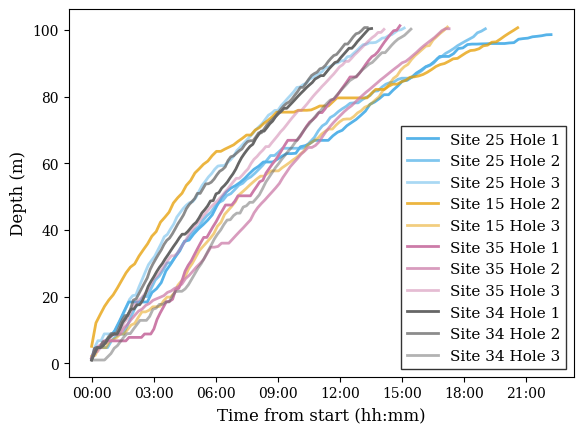

In [22]:
# Hole -> shade index within a site (1->0, 2->1, 3->2, 4->0, ...)
fig = plt.figure(figsize=(6, 4.5))
ax = fig.subplots()

for spine in ax.spines.values():
    spine.set_color('black')
ax.tick_params(axis='both', colors='black')


for (number, site, hole), idx in hole_groups.groups.items():
    data = mdf.loc[idx, ['[PLC]WIRESPOOLEDOUT', 'hole_duration']].cummax()
    # Choose 100 evenly spaced points and subsample the data
    subset_idx = np.round(np.linspace(0, data.shape[0]-1, 100)).astype(int)
    subsample = data.iloc[subset_idx]

    shade_idx = (int(hole) - 1) % 3
    color = site_shades[site][shade_idx]
    
    ax.plot(
        pd.to_datetime(subsample['hole_duration'], unit='s'),
        subsample['[PLC]WIRESPOOLEDOUT'],
        color=color,
        linewidth=2,
        label=f"Site {site} Hole {hole}",
    )

formatter = DateFormatter("%H:%M")
ax.xaxis.set_major_formatter(formatter)

ax.set_xlabel("Time from start (hh:mm)")
ax.set_ylabel("Depth (m)")
ax.legend(loc='best', frameon=True, fancybox=False, edgecolor='black', fontsize=11)
fig.tight_layout()
fig.savefig("paper_plots/performance-2025.pdf")
fig.show()

In [13]:
df.keys()

Index(['[PLC]AUTODOWNSTOPDEPTH', '[PLC]AUTOMODE', '[PLC]AUTOSEQ',
       '[PLC]CABLESPEED', '[PLC]CABLETENSION', '[PLC]CABLETENSIONGRAMS',
       '[PLC]DRILLACTIVECURRENT', '[PLC]DRILLFEEDBACKVEL', '[PLC]DRILLTEMP',
       '[PLC]ICECONVEYOR.SETSPEED', '[PLC]IMUPITCH',
       '[PLC]IMUPITCHRATEFILTERED', '[PLC]IMUROLL', '[PLC]IMUROLLRATEFILTERED',
       '[PLC]IMUYAW', '[PLC]IMUYAWRATEFILTERED', '[PLC]SNOWBLOWER.ACTUALRPM',
       '[PLC]WIRESPOOLEDOUT', 'run', 'cutting', 'cut_depth', 'weight_on_bit',
       'hole_pitch', 'hole_roll'],
      dtype='object', name='tag')

In [13]:
#@click.command
#@click.option("--folder", help="Folder containing BigRAID PLC logs", required=True)
#@click.option("--start", "start_date",
#              help="A start date in isoformat. Can optionally include a time as well.", required=True)
#@click.option("--end", "end_date",
#              default=None,
#              help="A end date. If not supplied, this defaults to end-of-day of the start date.")
#@click.option("--out", "out_file",
#              default=None,
#              help="Output path for the PDF. Defaults to a name based on the dates in the current folder")

In [69]:
# everything below here for reference
def _plot(df, out_path):
    # Add additional calculated columns to the data
    df = preprocess(df, run_depth_threshold=1.5)
    figures_start_idx = plt.gcf().number + 1

    df[df["cutting"] == 1].plot.scatter(x="cut_depth", y="[PLC]DRILLACTIVECURRENT", c="run", s =1, rasterized=True, cmap="viridis")
    #plt.title("Motor Current vs Running Cut Depth")
    plt.xlabel("Running Cut Depth [m]")
    plt.ylabel("Motor Current [A]")
    plt.ylim(0,6.5)
    plt.xlim(0,2.6)

    df[df["cutting"] == 1].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="[PLC]CABLETENSION", c="run", s =1, rasterized=True, cmap="viridis")
    #plt.title("Cable Tension vs Depth")
    plt.ylabel("Cable Tension [kg]")
    plt.xlabel("Depth [m]")
    plt.ylim(120,480)
    plt.xlabel("Depth [m]")
    plt.xlim(0,105)

    df[df["cutting"] == 1].plot.scatter(x="run", y="cut_depth",s =1, rasterized=True, cmap="viridis")
    #plt.title("Running Cut Depth per run")
    plt.ylabel("Running Cut Depth [m]")
    plt.xlabel("Run")
    plt.ylim(0,2.6)
    
    df[df["cutting"] == 1].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="cut_depth",s =1, rasterized=True, cmap="viridis")
    #plt.title("Running Cut Depth per run")
    plt.ylabel("Running Cut Depth [m]")
    plt.xlabel("Depth [m]")
    plt.ylim(0,2.6)


    df[df["cutting"] == 1].plot.scatter(x="cut_depth", y="[PLC]CABLETENSION", c="run", s =1, rasterized=True, cmap="viridis")
    #plt.title("Cable Tension vs Running Cut Depth")
    plt.ylabel("Cable Tension [kg]")
    plt.xlabel("Running Cut Depth [m]")
    plt.ylim(120,480)
    plt.xlim(0,2.6)

    df[df["cutting"] == 1].plot.scatter(x="cut_depth", y="[PLC]CABLETENSION", c="[PLC]CABLESPEED",s =1, rasterized=True, cmap="viridis")
    #plt.title("Cable Tension vs Running Cut Depth")
    plt.ylabel("Cable Tension [kg]")
    plt.xlabel("Running Cut Depth [m]")
    plt.ylim(120,480)
    plt.xlim(0,2.6)

    df[(df["cutting"] == 1)].plot.scatter(x="cut_depth", y="weight_on_bit", c="run",s =1, rasterized=True, cmap="viridis")
    #plt.title("Estimated Weight on Bit vs Running Cut Depth")
    plt.ylabel("Weight On Bit [kg]")
    plt.xlabel("Running Cut Depth [m]")
    plt.xlim(0,2.6)
    plt.ylim(0,180)

    df[df["cutting"] == 1].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="[PLC]DRILLFEEDBACKVEL", c="[PLC]CABLESPEED",s =1, rasterized=True, cmap="viridis")
    #plt.title("RPM vs Running Cut Depth")
    plt.ylabel("Motor speed [RPM]")
    plt.xlabel("Depth [m]")
    plt.ylim(60,140)
    plt.xlim(0,100)

    df[df["cutting"] == 1].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="[PLC]CABLESPEED", c="[PLC]DRILLFEEDBACKVEL",s =1, rasterized=True, cmap="viridis")
    #plt.title("RPM vs Running Cut Depth")
    plt.ylabel("Rate of penetration [m/min]")
    plt.xlabel("Depth [m]")
    plt.ylim(0,1)
    plt.xlim(0,100)

    def group_duration(x):
        diff = x.diff()
        return diff[diff < np.timedelta64(10, 's')].sum()
    total = df[df["run"] > 0].index.to_series().groupby(df["run"]).agg(np.ptp).dt.total_seconds().rename("total")
    cutting = df[df["cutting"] == 1].index.to_series().groupby(df["run"]).agg(np.ptp).dt.total_seconds().rename("cutting")
    moving = df[df["[PLC]CABLESPEED"] > 2].index.to_series().groupby(df["run"]).agg(group_duration).dt.total_seconds().rename("moving")
    ejecting = df[df["[PLC]DRILLFEEDBACKVEL"] < -5].index.to_series().groupby(df["run"]).agg(np.ptp).dt.total_seconds().rename("ejecting")
    if "[PLC]ICECONVEYOR.SETSPEED" in df.columns:
        snowblower_travel = df[df['[PLC]ICECONVEYOR.SETSPEED'].abs() > 1].index.to_series().groupby(df["run"]).agg(group_duration).dt.total_seconds().rename("snowblower_travel")
    else:
        snowblower_travel = pd.Series(np.zeros(cutting.shape)).rename("snowblower_travel")
    grps = pd.concat([total, moving, cutting, ejecting, snowblower_travel], axis=1).fillna(0.0)
    
    fig = plt.figure()
    ax = plt.subplot()
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    ax.bar(grps.index, grps['total'], color=colors[0], label="Total")
    ax.bar(grps.index, grps['cutting'], color=colors[1], label="Cutting")
    ax.bar(grps.index, grps['snowblower_travel'], color=colors[2], label="Snowblower Travel", bottom=grps['cutting'])
    ax.bar(grps.index, grps['ejecting'], color=colors[3], label="Ejecting", bottom=grps['cutting'] + grps['snowblower_travel'])
    ax.bar(grps.index, grps['moving'], color=colors[4], label="Moving", bottom=grps['cutting'] + grps['snowblower_travel'] + grps["ejecting"])
    ax.legend()
    #ax.set_title("Time per Run")
    ax.set_ylabel("Time [s]")
    ax.set_xlabel("Run")

    fig = plt.figure()
    ax = plt.subplot()
    run_cut_depth = df['cut_depth'].groupby(df['run']).max()
    run_cut_speed = (run_cut_depth / total) * 60 * 60
    run_auto_mode = df['[PLC]AUTOMODE'].groupby(df['run']).any()
    colors = ['tab:orange' if a else 'tab:blue' for a in run_auto_mode.values]
    labels = ['_A' if a else '_M' for a in run_auto_mode.values]
    if "_A" in labels:
        if (idx := labels.index("_A")) >= 0:
            labels[idx] = "Auto"
    if "_M" in labels:
        if (idx := labels.index("_M")) >= 0:
            labels[idx] = "Manual"
    ax.bar(run_cut_speed.index, run_cut_speed.values, color=colors, label=labels)

    # Plot the average
    ax.axhline(np.mean(run_cut_speed.values), 0, max(run_cut_speed.index))

    # Plot a regression line
    coeff = np.polyfit(run_cut_speed.index, run_cut_speed.values, 1)
    fit_fn = np.poly1d(coeff)
    ax.plot([0, max(run_cut_speed.index)], [fit_fn(0), fit_fn(max(run_cut_speed.index))], 'r--')

    fig.suptitle("Drilling Performance")
    ax.set_title("Cut length / Total time for the run")
    ax.set_ylabel("Drilling Performance [m/h]")
    ax.set_xlabel("Run")
    ax.legend(title="Mode")

    #fig, axes = plt.subplots(1, 3)
    display_max = 0
    for i, k in enumerate(["[PLC]IMUYAW","[PLC]IMUPITCH", "[PLC]IMUROLL"]):
        fig = plt.figure()
        ax = plt.subplot()
        d = df[(df["[PLC]WIRESPOOLEDOUT"] > 2)]
        # subtract the mean when the drill is hanging freely above the hole
        #zero_offset = df[(df["[PLC]WIRESPOOLEDOUT"] < 1) & (df["[PLC]CABLESPEED"].abs() < 0.1) & (df["[PLC]DRILLFEEDBACKVEL"].abs() < 0.1) & (df[k].abs() < 5.0)][k].mean()

        vals = d[k]# - zero_offset
        display_max = max(vals.abs().quantile(0.99), display_max)
        depth_max = df['[PLC]WIRESPOOLEDOUT'].max()
        #print(i,k, vals.values)
        if k=="[PLC]IMUYAW":
            xmin = -180
            xmax = 180
        elif  k=="[PLC]IMUROLL":
            xmin = -2
            xmax = 2
        elif  k=="[PLC]IMUPITCH":
            xmin = -2
            xmax = 2
        H, xedges, yedges = np.histogram2d(d["[PLC]WIRESPOOLEDOUT"], vals, bins=[int(depth_max/2), 50], range=[[0, depth_max], [xmin, xmax]])
        H_norm_rows = H / H.max(axis=1, keepdims=True)
        H_norm_rows = np.nan_to_num(H_norm_rows)
        ax.pcolormesh(yedges, xedges, H_norm_rows, rasterized=True, cmap="viridis")
        ax.set_title(k)
        ax.set_xlim(xmin, xmax)
        #ax.set_xlim(-display_max, display_max)
        #fig.title("Angle per Depth")
        ax.set_ylabel("Wire spooled out [m]")
        ax.set_xlabel("Angle [deg]")    
    yaw_rad = np.deg2rad(d["[PLC]IMUYAW"].values)
    pitch_rad= np.deg2rad(d["[PLC]IMUPITCH"].values)
    roll_rad = np.deg2rad(d["[PLC]IMUROLL"].values)

    fig, axes = plt.subplots(1, 2)
    display_max = 0
    for i, k in enumerate(["[PLC]IMUPITCH", "[PLC]IMUROLL"]):
        d = df[(df[k].abs() < 2) & (df["[PLC]WIRESPOOLEDOUT"] > 2)]
        # subtract the mean when the drill is hanging freely above the hole
        zero_offset = df[(df["[PLC]WIRESPOOLEDOUT"] < 1) & (df["[PLC]CABLESPEED"].abs() < 0.1) & (df["[PLC]DRILLFEEDBACKVEL"].abs() < 0.1) & (df[k].abs() < 5.0)][k].mean()

        vals = d[k] - zero_offset
        display_max = max(vals.abs().quantile(0.99), display_max)
        depth_max = df['[PLC]WIRESPOOLEDOUT'].max()
        H, xedges, yedges = np.histogram2d(d["[PLC]WIRESPOOLEDOUT"], d[k] - zero_offset, bins=[int(depth_max/2), 50], range=[[0, depth_max], [-2, 2]])
        H_norm_rows = H / H.max(axis=1, keepdims=True)
        H_norm_rows = np.nan_to_num(H_norm_rows)
        axes[i].pcolormesh(yedges, xedges, H_norm_rows, cmap="viridis")
        axes[i].set_title(k)
    for ax in axes:
        ax.set_xlim(-display_max, display_max)
    fig.suptitle("Angle per Depth")
    fig.supylabel("Wire spooled out [m]")
    fig.supxlabel("Angle [deg]")

    fig, axes = plt.subplots(1, 2)
    display_max = 0
    for i, k in enumerate(["hole_pitch", "hole_roll"]):
        d = df[(df[k].abs() < 2) & (df["[PLC]WIRESPOOLEDOUT"] > 2)]
        # subtract the mean when the drill is hanging freely above the hole
        zero_offset = df[(df["[PLC]WIRESPOOLEDOUT"] < 1) & (df["[PLC]CABLESPEED"].abs() < 0.1) & (df["[PLC]DRILLFEEDBACKVEL"].abs() < 0.1) & (df[k].abs() < 5.0)][k].mean()

        vals = d[k] - zero_offset
        display_max = max(vals.abs().quantile(0.99), display_max)
        depth_max = df['[PLC]WIRESPOOLEDOUT'].max()
        H, xedges, yedges = np.histogram2d(d["[PLC]WIRESPOOLEDOUT"], d[k] - zero_offset, bins=[int(depth_max/2), 50], range=[[0, depth_max], [-2, 2]])
        H_norm_rows = H / H.max(axis=1, keepdims=True)
        H_norm_rows = np.nan_to_num(H_norm_rows)
        axes[i].pcolormesh(yedges, xedges, H_norm_rows, cmap="viridis")

        # Plot a regression line
        coeff = np.polyfit(d["[PLC]WIRESPOOLEDOUT"].values, vals.values, 1)
        fit_fn = np.poly1d(coeff)
        axes[i].plot([fit_fn(0), fit_fn(depth_max)], [0, depth_max], 'r--')

        axes[i].set_title(k)
    for ax in axes:
        ax.set_xlim(-display_max, display_max)
    fig.suptitle("Angle per Depth, normalized using IMU Yaw")
    fig.supylabel("Wire spooled out [m]")
    fig.supxlabel("Angle [deg]")

    # Plot a 3D trajectory for the hole
    dz = 1.0
    mean_angles_x, std_dev_angles_x, angle_bin_sizes = calc_binned_angles(df, "hole_pitch", dz=dz)
    mean_angles_y, std_dev_angles_y, _= calc_binned_angles(df, "hole_roll", dz=dz)

    z_coords, x_mean, x_std, y_mean, y_std = calculate_trajectory_3d(
        mean_angles_x, std_dev_angles_x,
        mean_angles_y, std_dev_angles_y,
        dz=dz
    )
    plot_trajectory_3d(z_coords, x_mean, x_std, y_mean, y_std)

    # Do some stability checks on the trajectory.
    def _plot_stability(df_comp, subtitle):
        comp_mean_x, comp_std_x, _ = calc_binned_angles(df_comp, "hole_pitch", dz=dz)
        comp_mean_y, comp_std_y, _ = calc_binned_angles(df_comp, "hole_roll", dz=dz)

        comp_z_coords, comp_x_mean, comp_x_std, comp_y_mean, comp_y_std = calculate_trajectory_3d(
            comp_mean_x, comp_std_x,
            comp_mean_y, comp_std_y
        )

        plot_stability_comparison(z_coords, x_mean, x_std, y_mean, y_std, comp_z_coords, comp_x_mean, comp_y_mean, subtitle)

    ## Take only angles when the drill is moving up
    df_down = df[(df['[PLC]WIRESPOOLEDOUT'].diff() > 0) | (df["[PLC]CABLESPEED"].abs() < 0.1)].dropna()
    _plot_stability(df_down, "Downgoing subset")

    ## When the drill is moving up
    df_up = df[(df['[PLC]WIRESPOOLEDOUT'].diff() < 0) | (df["[PLC]CABLESPEED"].abs() < 0.1)].dropna()
    _plot_stability(df_up, "Upgoing subset")

    ## When the drill is drilling
    df_cutting = df[(df['cutting'] == 1) | (df["[PLC]CABLESPEED"].abs() < 0.1)].dropna()
    _plot_stability(df_cutting, "Drill is cutting subset")

    ## When the drill is not drilling
    df_cutting = df[(df['cutting'] == 0) | (df["[PLC]CABLESPEED"].abs() < 0.1)].dropna()
    _plot_stability(df_cutting, "Drill is not cutting subset")

    incl_mean, incl_std = calc_inclination(mean_angles_x, std_dev_angles_x,
                                           mean_angles_y, std_dev_angles_y)
    plot_inclination(z_coords, incl_mean, incl_std / np.sqrt(angle_bin_sizes))

    df.plot.scatter(y="[PLC]WIRESPOOLEDOUT", x="[PLC]AUTODOWNSTOPDEPTH", c="run", cmap="viridis")
    plt.title("Stop Depth vs Depth")

    df_plt = df[df["[PLC]WIRESPOOLEDOUT"] == df["[PLC]WIRESPOOLEDOUT"].cummax()]

    df[["run", "cutting", "cut_depth", "[PLC]WIRESPOOLEDOUT"]].plot(use_index=False, rasterized=True)
    plt.figure()
    sampling_time = 1
    xtime_seconds =  sampling_time*np.arange(0,len(df["cut_depth"].values))
    xtime = xtime_seconds/60/60
    plt.scatter(xtime, df["[PLC]WIRESPOOLEDOUT"].values, s=1, rasterized=True)
    plt.xlabel("time from start [hrs]")
    plt.ylabel("depth [m]")  


    # plt.show()
    with matplotlib.backends.backend_pdf.PdfPages(out_path) as pdf:
        for fig in range(figures_start_idx,  plt.gcf().number + 1):
            pdf.savefig(fig)
            plt.close(fig)

In [ ]:
if __name__ == "__main__":
    plot()